# 实验 3：二维拉回度量有没有一维指标缺少的方向信息？

核心问题：

> $2\times2$ 拉回度量的最大拉伸方向，是否指向真实吸引域边界的法向？

查询族扩展为

$$q(u,v)=(1-u)A+uB+v\eta_\perp.$$

$\eta_\perp$ 与 $A,B$ 都正交，并缩放到 $\|\eta_\perp\|=\|B-A\|$。这样 $u,v$ 的一个单位在状态空间中具有相同初始长度，方向夹角不会被坐标尺度人为决定。

## 1. 冻结源码

Notebook 固定到已经测试的三个源码文件，并逐一核对 SHA-256。

In [1]:
import hashlib
import importlib.util
from pathlib import Path
import subprocess
import sys
import urllib.request

required = {
    "jax": "jax[cpu]",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

CODE_REV = "4857757ad8d5127cb4b986695548c919275a4dc6"
BASE = Path("representation-geometry/experiments/hopfield-dynamic-geometry")
SOURCES = {
    "experiment_01_boundary_localization.py": "c40bf773180ccd7ebced4c9413851878ae868e27b0c7207b3d1ff1abd0f79ec2",
    "experiment_02_moving_boundary.py": "58bd4699e94bfc11b83678b1b305280008269d42977b2d67ecfc41c5420da86b",
    "experiment_03_2d_directional_geometry.py": "353d9d931b24539646e2a585f79f516d6efa1753150c18146bf93d660401139e",
}

def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

local_directory = Path.cwd() / BASE
if all((local_directory / name).is_file() and sha256(local_directory / name) == digest
       for name, digest in SOURCES.items()):
    source_directory = local_directory
else:
    source_directory = Path("/content/hopfield_dynamic_geometry")
    source_directory.mkdir(parents=True, exist_ok=True)
    for name, digest in SOURCES.items():
        path = source_directory / name
        url = (
            "https://raw.githubusercontent.com/Heptazero/nn-labs/"
            f"{CODE_REV}/{BASE.as_posix()}/{name}"
        )
        urllib.request.urlretrieve(url, path)
        if sha256(path) != digest:
            raise RuntimeError(f"源码哈希不匹配: {name}")

sys.path.insert(0, str(source_directory))
print("source:", source_directory)
print("revision:", CODE_REV)

source: /content/hopfield_dynamic_geometry
revision: 4857757ad8d5127cb4b986695548c919275a4dc6


## 2. 冻结条件与停止门

- 5 个 $\delta$ × 8 个 seed，共 40 个条件；
- $v\in[-0.3,0.3]$，真实边界对每个 $v$ 用长时检索独立二分；
- A、B 两端必须稳定，每条固定 $v$ 的查询线只能切换一次；
- 在真实边界上计算 $G=J^\top J$，取最大特征向量；
- $t=0$ 的两个坐标已配平，$G(0)$ 各向同性，因此方向未定义；只有 $\lambda_{max}/\lambda_{min}\ge1.05$ 才记录方向；
- 从 $t=1$ 起，要求 $G$ 中位夹角不超过 $5^\circ$，p90 不超过 $15^\circ$；
- 独立价值要求配对 seed 的角度优势，其 95% bootstrap CI 下界超过预定的 $1^\circ$ 裕量。

比较对象是 overlap 零线法向和 energy ridge 法向。这里把 $G$ 放在真实边界上读取，是一个有利于 $G$ 的条件性方向测试，不检验它能否独立找到边界位置。

In [2]:
from experiment_03_2d_directional_geometry import (
    DirectionalGeometryConfig,
    run_experiment,
    write_artifacts,
)

config = DirectionalGeometryConfig()
config

DirectionalGeometryConfig(N=60, seeds=(0, 1, 2, 3, 4, 5, 6, 7), requested_overlaps=(0.0,), gain=4.0, dt=0.02, metric_steps=300, boundary_steps=1200, kappa_min=0.0, kappa_max=1.0, kappa_points=201, boundary_tolerance=1e-10, boundary_margin_tolerance=1e-10, boundary_max_iterations=60, endpoint_speed_tolerance=1e-06, endpoint_margin_minimum=0.01, flat_relative_tolerance=1e-10, identifiable_contrast=1.1, evaluation_start_time=2.0, median_error_tolerance=0.01, p90_error_tolerance=0.025, required_identifiable_fraction=0.9, representative_seed=0, representative_overlap=0.5, deltas=(-0.3, -0.15, 0.0, 0.15, 0.3), u_points=81, v_min=-0.3, v_max=0.3, v_points=13, topology_u_points=41, boundary_iterations=35, anisotropy_threshold=1.05, direction_evaluation_start_time=1.0, median_angle_tolerance_deg=5.0, p90_angle_tolerance_deg=15.0, independent_angle_margin_deg=1.0, bootstrap_resamples=10000, bootstrap_seed=20260911, representative_delta=0.3, representative_time=1.0)

## 3. 运行正式二维扫描

CPU 上需要约两分钟。计算使用 float64；密集数组写盘时压成 float32。

output: /content/experiment_03_outputs


,passed_directional_geometry,supports_independent_directional_G_value,valid_topology_fraction,G_direction_coverage_after_start,moving_boundary_median_angle_after_start_deg,moving_boundary_p90_angle_after_start_deg,moving_boundary_median_first_sustained_time,paired_seed_angle_gain_over_G_deg,G_more_accurate_by_practical_margin,G_earlier_than_both_baselines,max_endpoint_speed,min_endpoint_margin_magnitude,median_boundary_curve_range
0,True,True,1.0,1.0,"{'energy_ridge_normal': 2.007946463161188, 'ov...","{'energy_ridge_normal': 5.020181427981804, 'ov...","{'energy_ridge_normal': 0.0, 'overlap_normal':...",{'overlap_normal': {'median': 1.33313446157395...,True,False,3.317456e-10,0.659906,0.045376


,delta,valid_topology,median_boundary_range
0,-0.30,1.0,0.064967
1,-0.15,1.0,0.035544
2,0.00,1.0,0.013570
3,0.15,1.0,0.035849
4,0.30,1.0,0.065635


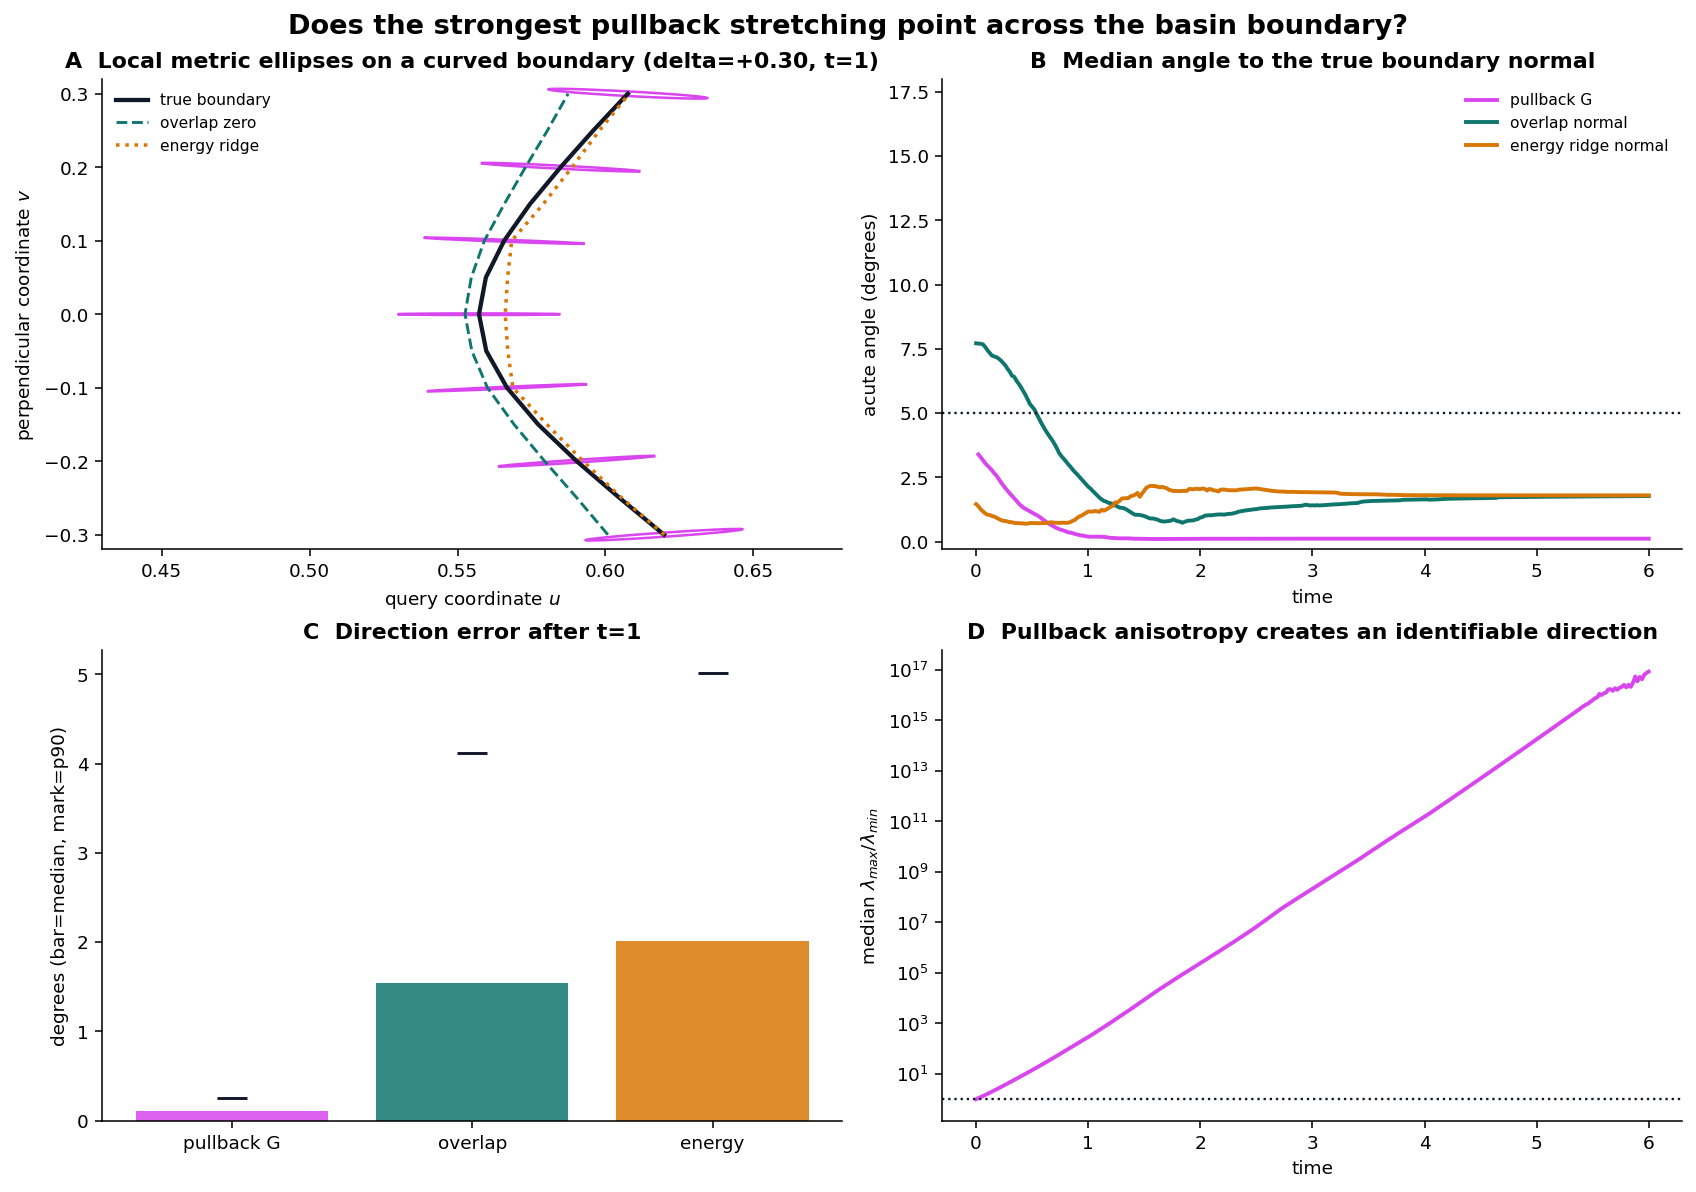

In [3]:
from IPython.display import display
import pandas as pd

conditions, boundaries, directions, raw = run_experiment(config)
output_dir = (
    Path("/content/experiment_03_outputs")
    if Path("/content").exists()
    else Path("/tmp/nn_labs_experiment_03_outputs")
)
summary, conclusion_path = write_artifacts(
    output_dir, conditions, boundaries, directions, raw, config
)

print("output:", output_dir)
display(pd.DataFrame([summary]))
display(
    conditions.groupby("delta", as_index=False).agg(
        valid_topology=("topology_status", lambda values: (values == "valid").mean()),
        median_boundary_range=("boundary_u_range", "median"),
    )
)

## 4. 主图

A 直接画出弯曲边界、两条基线曲线和局部度量椭圆。B、C 比较三种法向的夹角。D 显示动力学怎样把初始各向同性度量拉成具有明确主方向的椭圆。

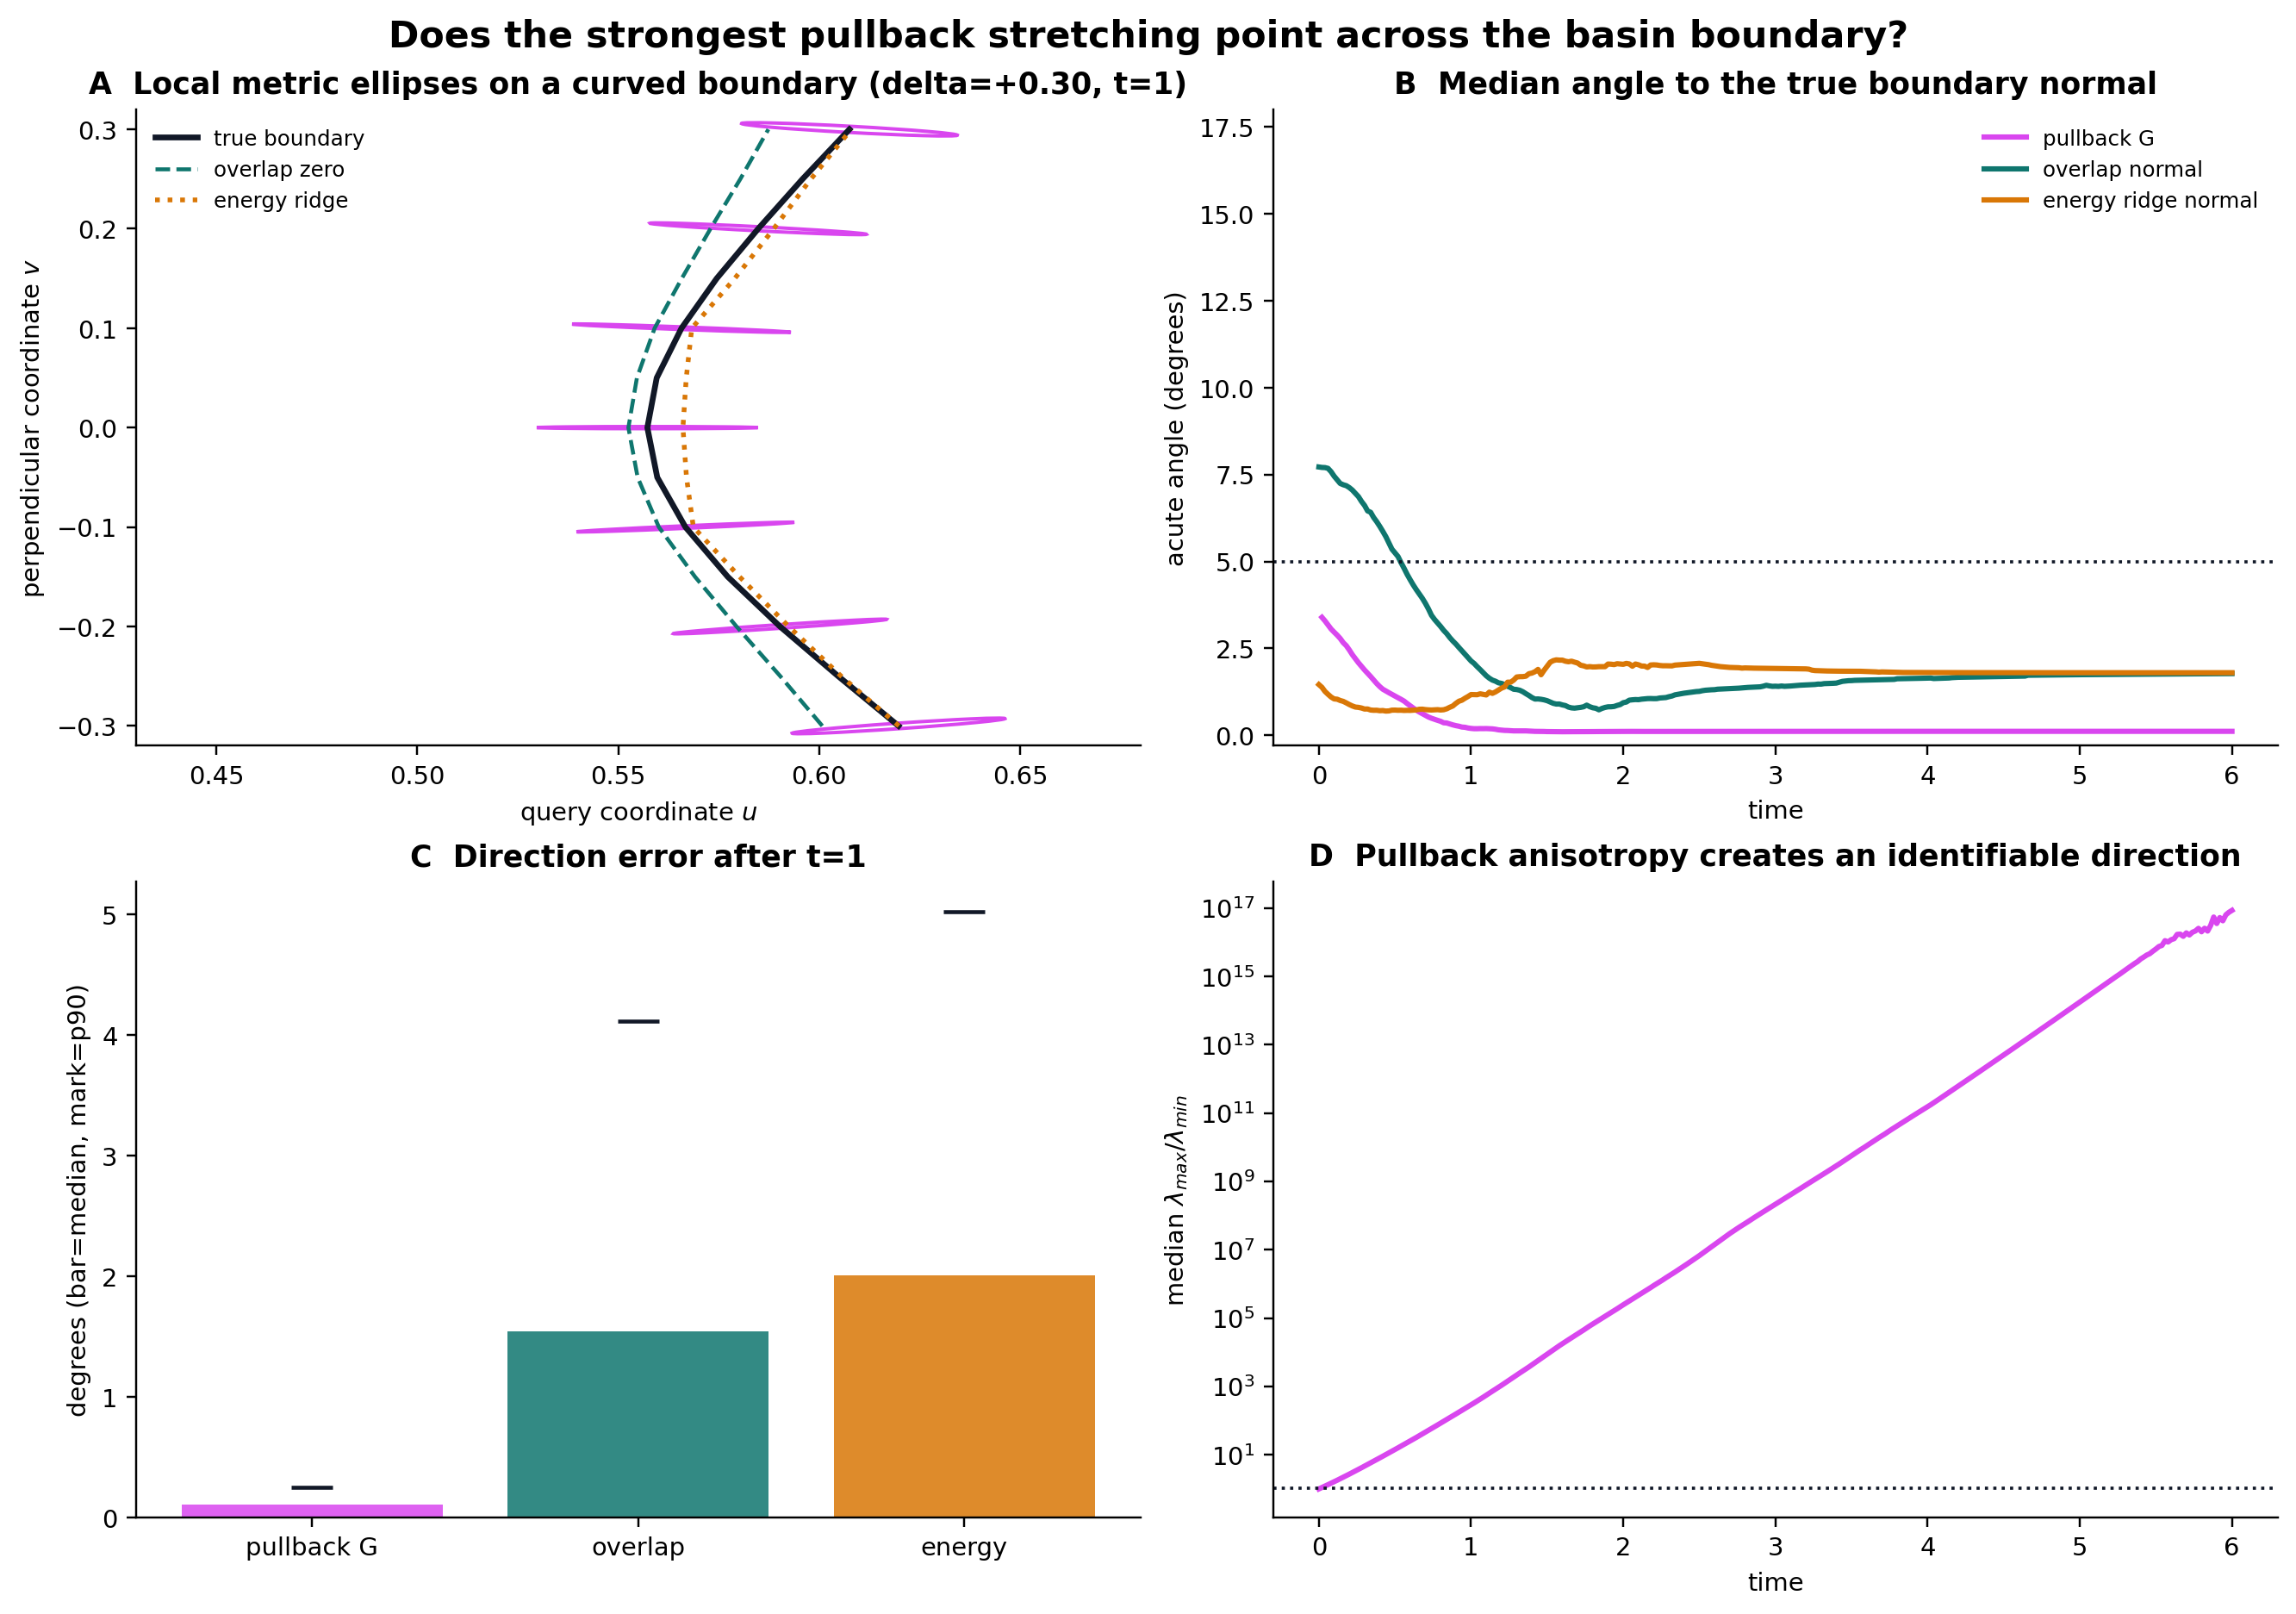

In [4]:
from IPython.display import Image, display

display(Image(filename=str(output_dir / "main_figure.png")))

## 5. 冻结结果

40 个条件全部通过拓扑检查，非零 $\delta$ 的边界曲线典型跨度约为 $0.045$。从 $t\ge1$ 起：

- pullback $G$ 主方向与真实法向的中位夹角为 $0.109^\circ$；
- overlap 零线法向为 $1.54^\circ$；
- energy ridge 法向为 $2.01^\circ$；
- G 相对 overlap 的配对 seed 优势为 $1.33^\circ$，95% CI $[1.21,1.67]$；
- G 相对 energy 的优势为 $1.84^\circ$，95% CI $[1.69,2.16]$。

所以这一次两层都通过：二维 $G$ 的主方向稳定指向边界法向，并以预定裕量优于两条简单基线。这是二维第一次提供一维标量没有的增量信息。

结论仍有明确边界：实验把 $G$ 放在真实边界上读取，因此它证明的是“边界附近的方向诊断”，不证明 $G$ 能从整个输入平面自行找到边界。

## 6. 原始产物

输出包括配置、拓扑检查、真实边界点、156,520 条逐时刻方向记录、紧凑数组、估计器汇总、主图和结论草稿。

In [5]:
import shutil

archive = shutil.make_archive(str(output_dir), "zip", root_dir=output_dir)
print("archive:", archive)
try:
    from google.colab import files
    print("在 Colab 中运行 files.download(archive) 即可下载。")
except ImportError:
    pass

archive: /content/experiment_03_outputs.zip
在 Colab 中运行 files.download(archive) 即可下载。
